<a href="https://colab.research.google.com/github/DhruvGangwar320/GitHUB/blob/main/dl_lecture_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [7]:
# now data is needed , which is slready in tensorflow
(x_train,y_train) , (x_test,y_test)=tf.keras.datasets.mnist.load_data()

In [8]:
x_train.shape

(60000, 28, 28)

In [10]:
x_test.shape

(10000, 28, 28)

In [11]:
# We want to see this data
# with the help of openCV we can do it
# here we will do it with matplotlib
import matplotlib.pyplot as plt


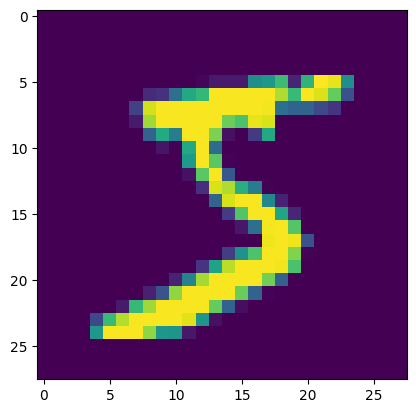

In [12]:
plt.imshow(x_train[0])

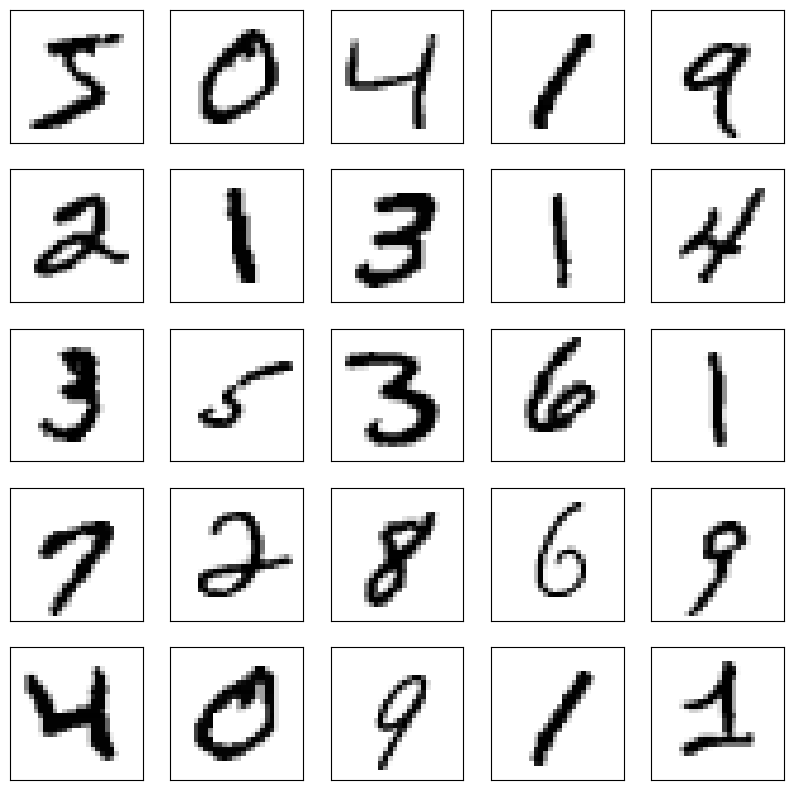

In [19]:
plt.figure(figsize =(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_train[i],cmap = plt.cm.binary)
plt.show()

In [21]:
# when data comes in the form of images
# we will normalize the data
x_train = x_train / 255.0 # color range is 0 to 255 if we will divide it by 255 then scalling we come
x_test = x_test / 255.0# range 0  to 1

In [32]:
# How to create a model
# from images is 2d array
# comvert it into 1d array using flatten function
model = Sequential([
    #Input Layer
    Flatten(input_shape = (28,28)),
    #Input layer will have 284 neurons (28*28)
    #Now hidden layer
    # We use Dense(numebr of neurons  activation function) method to make layer
    Dense(512 , activation = "sigmoid"),
    Dense(256 , activation = "sigmoid"),
    Dense(128 , activation = "sigmoid"),
    # Output layer
    Dense(10,activation = "softmax")
    # Dense(1,activation = 'sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(optimizer = 'adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits =True),
              metrics = ['accuracy'])

In [37]:
model.fit(x_train,y_train, validation_data =(x_test,y_test),epochs = 9)

Epoch 1/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8044 - loss: 0.5889 - val_accuracy: 0.8239 - val_loss: 0.5387
Epoch 2/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8290 - loss: 0.5249 - val_accuracy: 0.8443 - val_loss: 0.4906
Epoch 3/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8404 - loss: 0.4952 - val_accuracy: 0.8523 - val_loss: 0.4602
Epoch 4/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8510 - loss: 0.4699 - val_accuracy: 0.8624 - val_loss: 0.4219
Epoch 5/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8633 - loss: 0.4269 - val_accuracy: 0.8801 - val_loss: 0.3787
Epoch 6/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8768 - loss: 0.3872 - val_accuracy: 0.8880 - val_loss: 0.3598
Epoch 7/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8837 - loss: 0.3643 - val_accuracy: 0.8882 - val_loss: 0.3539
Epoch 8/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8888 - loss: 0

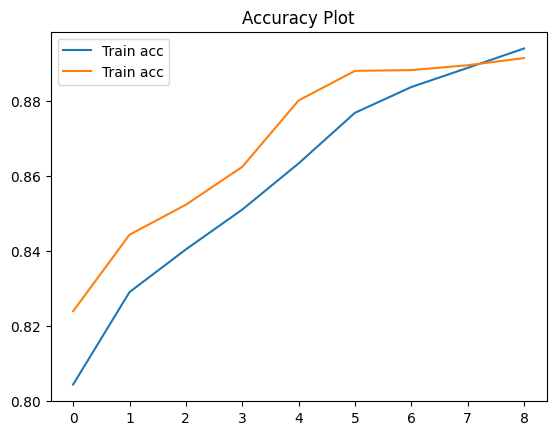

In [38]:
plt.plot(model.history.history['accuracy'] , label = "Train acc")
plt.plot(model.history.history['val_accuracy'] , label = "Train acc")
plt.legend()
plt.title('Accuracy Plot')
plt.show()

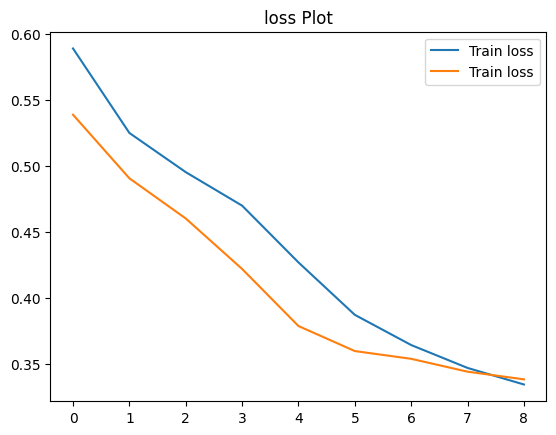

In [41]:
plt.plot(model.history.history['loss'] , label = "Train loss")
plt.plot(model.history.history['val_loss'] , label = "Train loss")
plt.legend()
plt.title('loss Plot')
plt.show()